In [1]:
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from IPython.display import display
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import prepare_data
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm


def rolling_collinearity(X: pd.DataFrame, window: int = 252, step: int = 1):
    """
    係数ローリング回帰と同一窓で VIF・条件数を時系列算出。
    X: 説明変数のみ（被説明変数は含めない）
    """
    cols = X.columns.tolist()
    idx, vif_rows, cond_rows = [], [], []

    for end in range(window, len(X) + 1, step):
        win = X.iloc[end - window : end]
        # 窓内に分散ゼロ列がないか確認（祝日ゼロ埋め等の残存対策）
        if (win.std() == 0).any():
            continue
        Xc = sm.add_constant(win)
        vifs = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
        vif_rows.append(dict(zip(Xc.columns, vifs)))

        Xs = (win - win.mean()) / win.std()
        cond_rows.append(np.linalg.cond(sm.add_constant(Xs).values))
        idx.append(X.index[end - 1])

    vif_ts = pd.DataFrame(vif_rows, index=idx).drop(columns="const")
    cond_ts = pd.Series(cond_rows, index=idx, name="cond_number")
    return vif_ts, cond_ts


def rolling_correlation(X: pd.DataFrame, window: int = 256, step: int = 1):
    """
    説明変数間の全ペア相関を、係数ローリング回帰と同一窓で時系列算出。
    X: 説明変数のみ（被説明変数は含めない）
    戻り値: corr_ts (各列が変数ペア, 値はその窓のpairwise相関)
    """
    from itertools import combinations

    cols = X.columns.tolist()
    pairs = list(combinations(cols, 2))
    idx, rows = [], []

    for end in range(window, len(X) + 1, step):
        win = X.iloc[end - window : end]
        if (win.std() == 0).any():  # 分散ゼロ列（祝日ゼロ埋め残存等）を回避
            continue
        c = win.corr()
        rows.append({f"{a} × {b}": c.loc[a, b] for a, b in pairs})
        idx.append(X.index[end - 1])

    return pd.DataFrame(rows, index=idx)


def rolling_factor_regression(
    df_daily_return,
    window=252,
    maxlags=21,
    y_col="Quality",
    x_cols=("Value", "Size", "Momentum", "Low Volatility", "Growth"),
):
    X = sm.add_constant(df_daily_return[list(x_cols)])
    y = df_daily_return[y_col]

    rolling_results = []
    dates = df_daily_return.index

    for i in range(window, len(df_daily_return) + 1):
        X_slice = X.iloc[i - window : i]
        y_slice = y.iloc[i - window : i]
        current_date = dates[i - 1]

        try:
            model = sm.OLS(y_slice, X_slice).fit(
                cov_type="HAC", cov_kwds={"maxlags": maxlags}
            )
            row_data = {"Date": current_date, "R_squared": model.rsquared}
            # 各変数のcoefとz-value(t-value)を格納
            for col in X.columns:
                row_data[f"coef_{col}"] = model.params[col]
                row_data[f"zstat_{col}"] = model.bse[col]

            rolling_results.append(row_data)
        except Exception as e:
            print(f"Error at {current_date}: {e}")
            continue

    df_rolling = pd.DataFrame(rolling_results).set_index("Date")
    return df_rolling


def preprocess_return_data(
    df_return: pd.DataFrame,
    target_sector: str | None = None,
    factors: list[str] | None = None,
) -> pd.DataFrame:
    if not factors:
        factors = [
            "Momentum",
            "Low Volatility",
            "Size",
            "Value",
            "Growth Long-Short",
            "Quality",
        ]

    if not target_sector:
        target_cols = [
            "FTW MXWD Index " + f + " (High-Low) Total Return"
            if f == "Growth Long-Short"
            else "FTW MXWD Index " + f + " Long-Short (High-Low) Total Return"
            for f in factors
        ]
        target_cols = [
            f.replace("High-Low", "Low-High")
            if any(factor in f for factor in ["Low Volatility", "Value"])
            else f
            for f in target_cols
        ]
    else:
        key_cols = f"FTW MXWD Index {target_sector}"
        target_cols = [
            s
            for s in df_return.columns
            if (key_cols in s) and any(f in s for f in factors)
        ]

    return_data = df_return[target_cols].copy()

    return_data.columns = [
        s.replace(f"FTW MXWD Index {target_sector} ", "")
        .replace(f"FTW MXWD Index ", "")
        .replace(" Long-Short (High-Low) Total Return", "")
        .replace(" Long-Short (Low-High) Total Return", "")
        .replace("Sector Neutralized ", "")
        for s in return_data.columns
    ]
    return_data = return_data[~(return_data == 0).all(axis=1).copy()].dropna(how="any")

    return return_data


PRJ_DIR = Path().cwd()
parquet_file = PRJ_DIR / "MSCI ACWI_FTW-LS-cum.parquet"
df_cum = prepare_data.get_factor_cum_return(parquet_file)
df_daily_factor_return = prepare_data.arithmetic_cumret_to_daily(parquet_file)
display(df_daily_factor_return.head())


[情報] 全ゼロ行(非取引日)を 1670 件除去する。
[完了] 5420 行。 中央絶対値 0.00330(小数)。 期間 2007-01-02 〜 2026-05-29。


variable,FTW MXWD Index 1Y Fwd EPS Growth (FY) % Long-Short (High-Low) Total Return,FTW MXWD Index Communications 1Y Fwd EPS Growth (FY) % Long-Short (High-Low) Total Return,FTW MXWD Index Communications Dividend Yield Long-Short (High-Low) Total Return,FTW MXWD Index Communications Growth Long-Short (High-Low) Total Return,FTW MXWD Index Communications Low Volatility Long-Short (Low-High) Total Return,FTW MXWD Index Communications Market Capitalization Long-Short (High-Low) Total Return,FTW MXWD Index Communications Momentum Long-Short (High-Low) Total Return,FTW MXWD Index Communications Qtly EPS Acceleration Long-Short (High-Low) Total Return,FTW MXWD Index Communications Quality Long-Short (High-Low) Total Return,FTW MXWD Index Communications Size Long-Short (High-Low) Total Return,...,FTW MXWD Index Utilities Dividend Yield Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Growth Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Low Volatility Long-Short (Low-High) Total Return,FTW MXWD Index Utilities Market Capitalization Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Momentum Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Qtly EPS Acceleration Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Quality Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Size Long-Short (High-Low) Total Return,FTW MXWD Index Utilities Value Long-Short (Low-High) Total Return,FTW MXWD Index Value Long-Short (Low-High) Total Return
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-02,-0.0009,NaN,NaN,NaN,NaN,0.0013,-0.0007,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0054,NaN,NaN,0.0078,0.0003,NaN,0.0012
2007-01-03,-0.0038,0.0003,-0.0025,0.0006,-0.0029,0.0049,-0.0007,NaN,-0.0059,0.0061,...,0.0085,0.0024,0.0033,-0.0041,-0.0001,NaN,-0.0106,-0.0060,-0.0159,-0.0009
2007-01-04,-0.0054,-0.0028,-0.0042,0.0156,-0.0025,0.0075,-0.0027,NaN,-0.0030,0.0057,...,0.0029,-0.0110,-0.0168,-0.0062,-0.0039,NaN,-0.0024,0.0041,-0.0162,-0.0021
2007-01-05,0.0010,0.0022,-0.0044,0.0097,-0.0058,0.0020,-0.0064,NaN,-0.0021,0.0016,...,0.0020,0.0030,-0.0030,-0.0214,-0.0247,NaN,-0.0037,-0.0073,-0.0120,-0.0015
2007-01-06,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,NaN,0.0000,0.0000,...,0.0000,0.0000,-0.0000,0.0000,0.0000,NaN,0.0000,0.0000,-0.0000,-0.0000


In [2]:
dfs_return_data_by_sector = {}
for sector in [
    "Communications",
    "Consumer Discretionary",
    "Consumer Staples",
    "Technology",
    "Financials",
    "Industrials",
    "Health Care",
    "Materials",
    # "Utilities",
    # "Energy",
    # "Real Estate",
    "Sector Neutralized",
    None,
]:
    return_data = preprocess_return_data(
        df_return=df_daily_factor_return, target_sector=sector
    )
    if not sector:
        sector = "Not Sector Neutralized"
    dfs_return_data_by_sector.update({sector: return_data})


## VIF確認


  0%|          | 0/10 [00:00<?, ?it/s]

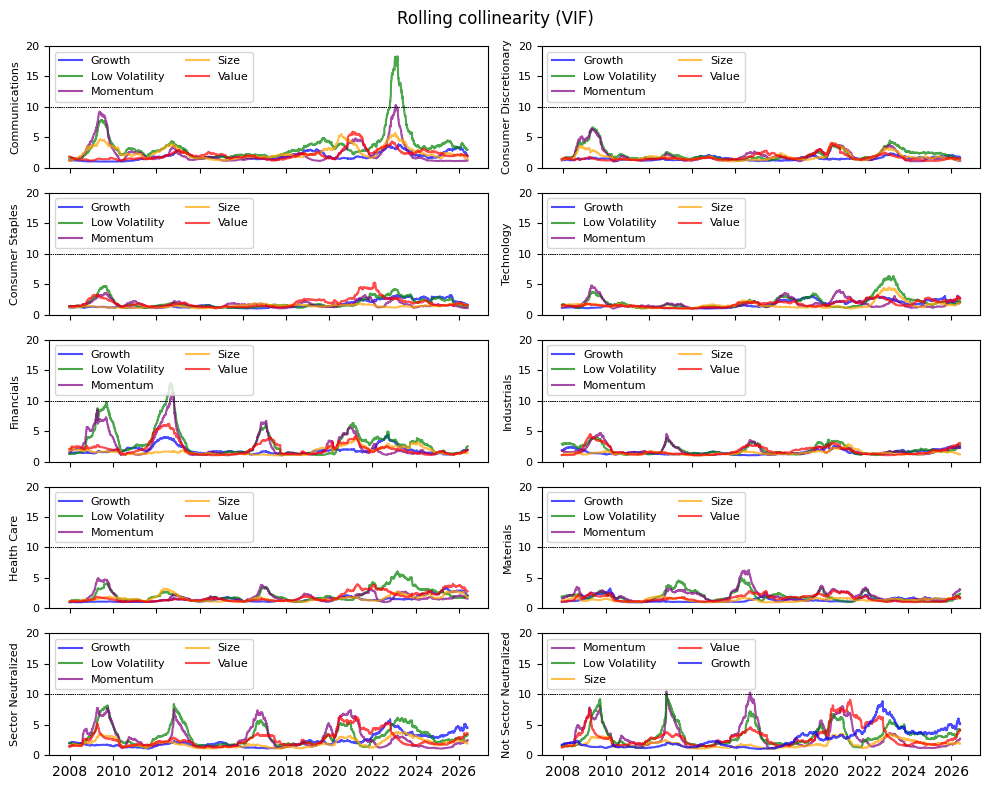

In [3]:
dfs_vif_ts = {}
for sector in tqdm(dfs_return_data_by_sector.keys()):
    return_data = dfs_return_data_by_sector[sector]
    vif_ts, cond_ts = rolling_collinearity(
        return_data[[c for c in return_data.columns if c != "Quality"]],
    )

    dfs_vif_ts.update({sector: vif_ts})

fig, axes = plt.subplots(5, 2, figsize=(10, 8), tight_layout=True, sharex=True)
fig.suptitle("Rolling collinearity (VIF)")
factor_color_map = {
    "Growth": "blue",
    "Momentum": "purple",
    "Value": "red",
    "Low Volatility": "green",
    "Size": "orange",
}
for idx, sector in enumerate(
    [s for s in dfs_vif_ts.keys() if not s in ["Utilities", "Energy", "Real Estate"]]
):
    ax = axes[idx // 2][idx % 2]
    vif_ts = dfs_vif_ts[sector]

    for col in vif_ts.columns:
        ax.plot(
            vif_ts.index, vif_ts[col], label=col, color=factor_color_map[col], alpha=0.7
        )
        ax.axhline(y=10, linewidth=0.5, color="black", ls="dotted")
        ax.set_ylim(0, 20)
        ax.set_ylabel(sector, fontsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.show()


## ファクターLSのボラティリティ


In [3]:
window = 252
vol_factors = {}
for sector in dfs_return_data_by_sector.keys():
    return_data = dfs_return_data_by_sector[sector]
    vol_factor = (
        return_data.rolling(window=window, min_periods=window).std() * np.sqrt(252)
    ).dropna(how="all")

    vol_factor.rename(
        columns={
            key: value
            for key, value in zip(
                vol_factor.columns, [c + "_vol" for c in vol_factor.columns]
            )
        },
        inplace=True,
    )

    if sector == "Not Sector Neutralized":
        cumulative_return_cols = [
            "FTW MXWD Index Quality Long-Short (High-Low) Total Return",
            "FTW MXWD Index Growth Long-Short (High-Low) Total Return",
            "FTW MXWD Index Momentum Long-Short (High-Low) Total Return",
            "FTW MXWD Index Size Long-Short (High-Low) Total Return",
            "FTW MXWD Index Value Long-Short (Low-High) Total Return",
            "FTW MXWD Index Low Volatility Long-Short (Low-High) Total Return",
        ]
    else:
        cumulative_return_cols = [
            f"FTW MXWD Index {sector} Quality Long-Short (High-Low) Total Return",
            f"FTW MXWD Index {sector} Growth Long-Short (High-Low) Total Return",
            f"FTW MXWD Index {sector} Momentum Long-Short (High-Low) Total Return",
            f"FTW MXWD Index {sector} Size Long-Short (High-Low) Total Return",
            f"FTW MXWD Index {sector} Value Long-Short (Low-High) Total Return",
            f"FTW MXWD Index {sector} Low Volatility Long-Short (Low-High) Total Return",
        ]

    vol_factor = pd.merge(
        vol_factor,
        df_cum[cumulative_return_cols],
        left_index=True,
        right_index=True,
    )

    vol_factors.update({sector: vol_factor})


### Sector Neutralized


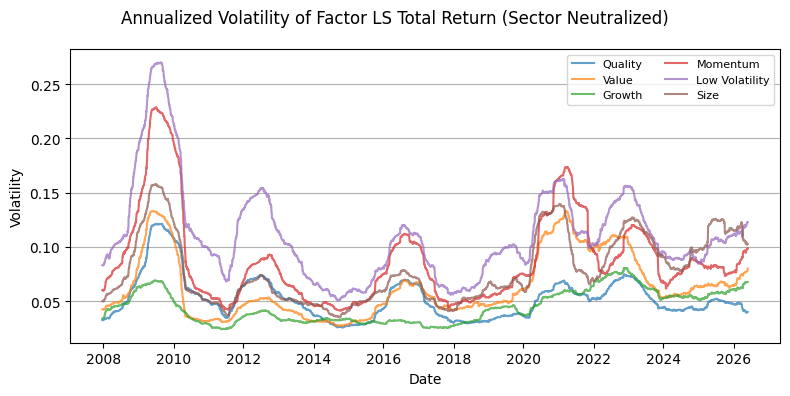

In [4]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
fig.suptitle("Annualized Volatility of Factor LS Total Return (Sector Neutralized)")

ax.grid(axis="y")
for factor in ["Quality", "Value", "Growth", "Momentum", "Low Volatility", "Size"]:
    vol_factor = vol_factors["Sector Neutralized"]
    ax.plot(vol_factor.index, vol_factor[f"{factor}_vol"], label=factor, alpha=0.7)
ax.set_ylabel("Volatility")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=8, ncols=2)

plt.show()


### セクター間比較


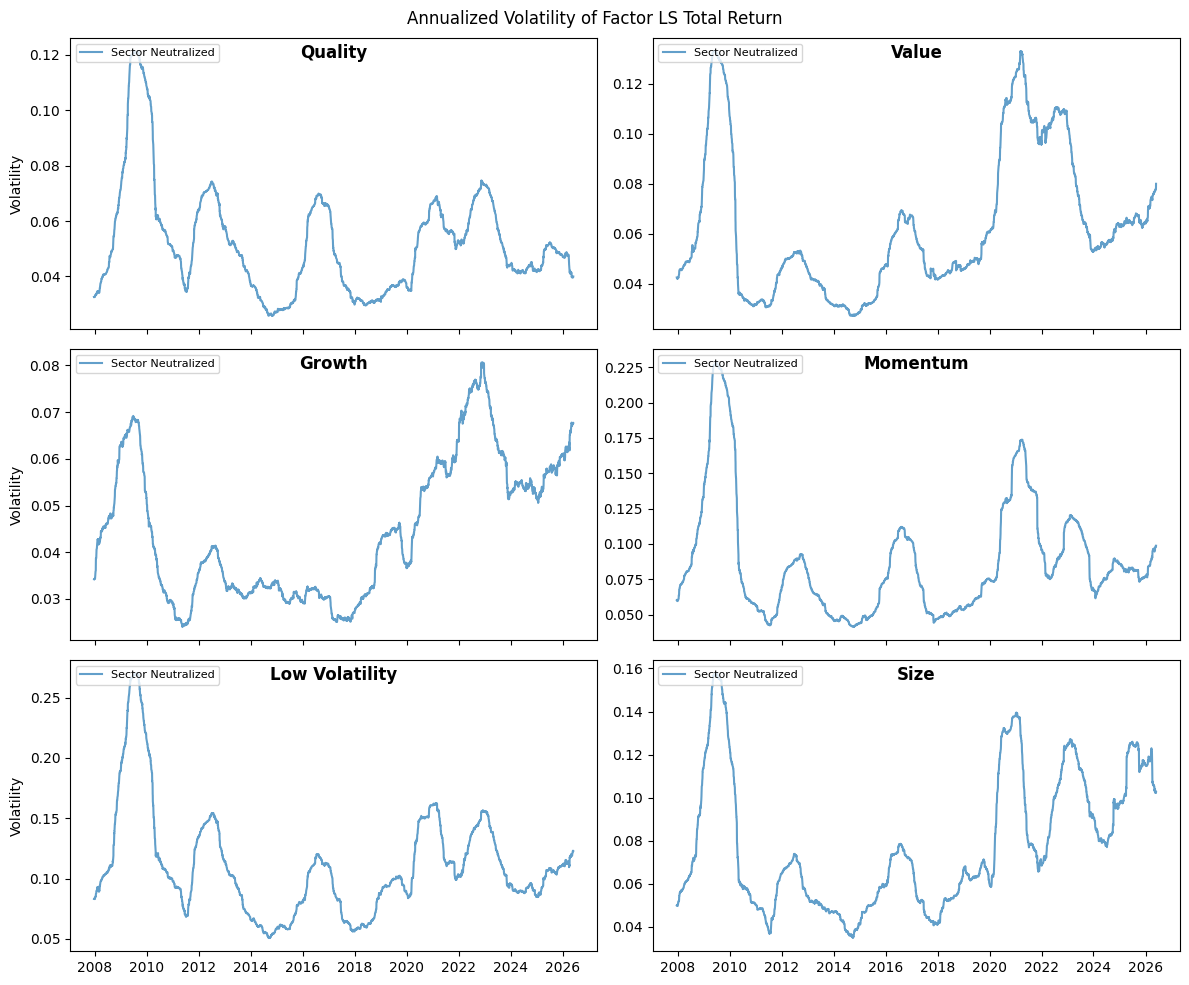

In [19]:
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 10), sharex=True, tight_layout=True
)
fig.suptitle("Annualized Volatility of Factor LS Total Return")

for idx, factor in enumerate(
    ["Quality", "Value", "Growth", "Momentum", "Low Volatility", "Size"]
):
    ax = axes[idx // 2][idx % 2]
    ax.set_title(
        factor,
        y=0.95,
        va="top",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
    # for sector in vol_factors.keys():
    for sector in ["Sector Neutralized"]:
        vol_factor = vol_factors[sector]
        ax.plot(vol_factor.index, vol_factor[f"{factor}_vol"], label=sector, alpha=0.7)
    if idx % 2 == 0:
        ax.set_ylabel("Volatility")
    ax.legend(loc="upper left", fontsize=8)
plt.show()


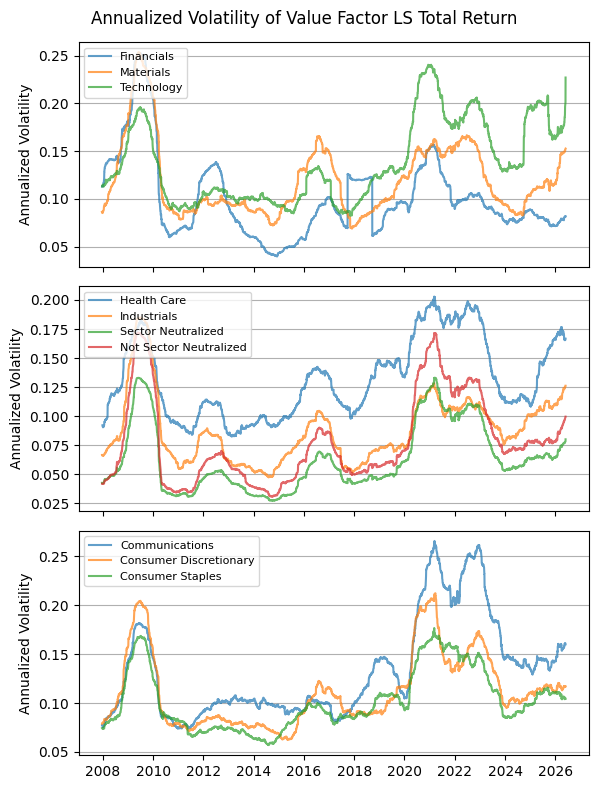

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True, tight_layout=True)
fig.suptitle("Annualized Volatility of Value Factor LS Total Return")

ax1 = axes[0]
ax1.grid(axis="y")
for sector in ["Financials", "Materials", "Technology"]:
    vol_factor = vol_factors[sector]
    ax1.plot(vol_factor.index, vol_factor["Value_vol"], label=sector, alpha=0.7)
    ax1.set_ylabel("Annualized Volatility")
ax1.legend(loc="upper left", fontsize=8)

ax2 = axes[1]
ax2.grid(axis="y")
for sector in [
    "Health Care",
    "Industrials",
    "Sector Neutralized",
    "Not Sector Neutralized",
]:
    vol_factor = vol_factors[sector]
    ax2.plot(vol_factor.index, vol_factor["Value_vol"], label=sector, alpha=0.7)
    ax2.set_ylabel("Annualized Volatility")
ax2.legend(loc="upper left", fontsize=8)

ax3 = axes[2]
ax3.grid(axis="y")
for sector in ["Communications", "Consumer Discretionary", "Consumer Staples"]:
    vol_factor = vol_factors[sector]
    ax3.plot(vol_factor.index, vol_factor["Value_vol"], label=sector, alpha=0.7)
    ax3.set_ylabel("Annualized Volatility")
ax3.legend(loc="upper left", fontsize=8)


plt.show()


In [21]:
window = 252
return_data = dfs_return_data_by_sector["Sector Neutralized"]
df_rolling_res = rolling_factor_regression(
    df_daily_return=return_data, window=window, maxlags=21
)


fig = make_subplots(specs=[[{"secondary_y": True}]])

# ファクターベータと決定係数の時系列推移
coef_cols = [c for c in df_rolling_res.columns if "coef_" in c and "const" not in c]
# coef_cols = ["coef_Value", "coef_Growth"]
for col in coef_cols:
    fig.add_trace(
        go.Scatter(
            x=df_rolling_res.index,
            y=df_rolling_res[col],
            mode="lines",
            name=col.replace("coef_", ""),
            opacity=0.7,
        ),
        secondary_y=False,
    )

fig.add_trace(
    go.Scatter(
        x=df_rolling_res.index,
        y=df_rolling_res["coef_const"] * 252,
        mode="lines",
        name="Annualized Alpha",
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_rolling_res.index,
        y=df_rolling_res["R_squared"],
        mode="lines",
        name="R-squared(RHS)",
        line=dict(color="white", width=2.5, dash="dash"),
    ),
    secondary_y=True,
)


fig.update_layout(
    title=f"Rolling Factor Betas(LHS) and R-squared(RHS) (window: {window} days)",
    xaxis_title="Date",
    template="plotly_dark",
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
    margin=dict(l=50, r=50, t=50, b=40),
)

fig.update_yaxes(title_text="Beta Coefficient", secondary_y=False)
fig.update_yaxes(title_text="R-squared", range=[0, 1], secondary_y=True)

fig.show()


In [22]:
window = 252

fig = go.Figure()

for sector in dfs_return_data_by_sector.keys():
    return_data = dfs_return_data_by_sector[sector]
    df_rolling_res = rolling_factor_regression(
        df_daily_return=return_data, window=window, maxlags=21
    )

    fig.add_trace(
        go.Scatter(
            x=df_rolling_res.index,
            y=df_rolling_res["coef_const"] * 252,
            name=sector,
            mode="lines",
            line=dict(width=1),
        )
    )

fig.update_layout(
    title=f"Annualized Alpha for each sector (window: {window} days)",
    xaxis_title="Date",
    template="plotly_dark",
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
    margin=dict(l=50, r=50, t=50, b=40),
)

fig.show()


In [31]:
vol_factor = vol_factors["Sector Neutralized"]

fig = make_subplots(specs=[[{"secondary_y": True}]])
for col in [
    c
    for c in vol_factor.columns
    if (c.endswith("_vol")) & any(f in c for f in ["Quality", "Value", "Growth"])
]:
    fig.add_trace(
        go.Scatter(x=vol_factor.index, y=vol_factor[col], name=col, mode="lines"),
        secondary_y=False,
    )

for col in [
    c
    for c in vol_factor.columns
    if any(
        s in c for s in ["Quality Long-Short", "Value Long-Short", "Growth Long-Short"]
    )
]:
    fig.add_trace(
        go.Scatter(
            x=vol_factor.index,
            y=vol_factor[col],
            name=col,
            mode="lines",
            line=dict(width=2.5),
        ),
        secondary_y=True,
    )


fig.update_layout(
    title=f"Factor Return and Rolling Volatility (window: {window} days)",
    xaxis_title="Date",
    template="plotly_dark",
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
    margin=dict(l=50, r=50, t=50, b=40),
)
fig.update_yaxes(title_text="Annualized Volatility", secondary_y=False)
fig.update_yaxes(title_text="Factor LS Total Return", secondary_y=True)


fig.show()


## ファクター間平均ペアワイズ相関

- 6ファクター(Quality, Value, Growth, Momentum, Low Vol, Size)の L/S リターン間の相関行列を、ローリング窓で時系列推定する。相関行列の非対角成分の平均を「平均ペアワイズ相関」とする。
- 経済的解釈は次の通り。各ファクター L/S リターンは、本来それぞれ固有のドライバー(クオリティはマージン、バリューはマルチプル等)を持ち、独立に動くのが「正常」な状態である。これらが一斉に高相関化する局面とは、個別ファクターの固有性が消え、市場全体が単一のマクロ要因(リスクオン/オフ、金利、流動性)に支配されている状態を意味する。López de Prado 的に言えば、ファクター・ユニバースの実効次元が低下している。これが D4 の「市場全体が単一レジームで凪」という主張の直接的な観測対象になる。


In [5]:
# D4対象: 全市場セクター中立版の主要6ファクター
sector = "Sector Neutralized"
target_cols = {
    f"FTW MXWD Index {sector} Quality Long-Short (High-Low) Total Return": "Quality",
    f"FTW MXWD Index {sector} Value Long-Short (Low-High) Total Return": "Value",
    f"FTW MXWD Index {sector} Growth Long-Short (High-Low) Total Return": "Growth",
    f"FTW MXWD Index {sector} Momentum Long-Short (High-Low) Total Return": "Momentum",
    f"FTW MXWD Index {sector} Low Volatility Long-Short (Low-High) Total Return": "LowVol",
    f"FTW MXWD Index {sector} Size Long-Short (High-Low) Total Return": "Size",
}
ret = df_daily_factor_return[list(target_cols)].rename(columns=target_cols)

# 欠損確認。相関の標本期間を揃えたい場合は listwise dropna
print(f"欠損セル: {int(ret.isna().sum().sum())}")
ret = ret.dropna()  # 6ファクターで完全観測の日のみ使用(期間整合のため)
print(f"分析対象: {len(ret)} 行 / {ret.index.min().date()}〜{ret.index.max().date()}")


欠損セル: 0
分析対象: 5420 行 / 2007-01-02〜2026-05-29


In [6]:
from itertools import combinations


def rolling_pairwise_corr(returns: pd.DataFrame, window: int = 252):
    """
    非対角成分の符号付き平均・絶対値平均を日次step=1で計算。
    戻り値: mean_signed, mean_abs (ともに pd.Series)
    """

    n = returns.shape[1]
    pairs = list(combinations(range(n), 2))  # 6C2 = 15ペア
    idx = returns.index
    mean_signed = pd.Series(index=idx, dtype=float)
    mean_abs = pd.Series(index=idx, dtype=float)

    vals = returns.values
    for end in range(window, len(returns) + 1):
        win = vals[end - window : end]
        C = np.corrcoef(win, rowvar=False)  # 6x6 相関行列
        offdiag = np.array([C[i, j] for i, j in pairs])
        mean_signed.iloc[end - 1] = np.nanmean(offdiag)
        mean_abs.iloc[end - 1] = np.nanmean(np.abs(offdiag))
    return mean_signed.dropna(), mean_abs.dropna()


# 窓長頑健性のため複数窓
windows = [63, 126, 252]
results = {}
for w in windows:
    s, a = rolling_pairwise_corr(ret, w)
    results[w] = {"signed": s, "abs": a}


In [8]:
def rolling_each_pair_corr(returns, window=252):
    cols = returns.columns
    pairs = list(combinations(cols, 2))
    out = pd.DataFrame(
        index=returns.index, columns=[f"{a}-{b}" for a, b in pairs], dtype=float
    )
    for a, b in pairs:
        out[f"{a}-{b}"] = returns[a].rolling(window).corr(returns[b])
    return out.dropna(how="all")


def rolling_each_pair_corr_spearman(returns, window=252):
    from scipy.stats import spearmanr

    cols = returns.columns
    pairs = list(combinations(cols, 2))
    out = pd.DataFrame(
        index=returns.index, columns=[f"{a}-{b}" for a, b in pairs], dtype=float
    )

    for a, b in pairs:
        # 2列を結合して同期を取る
        df_pair = returns[[a, b]]

        # スピアマンのローリング相関を1ペアずつ計算
        # rolling().apply()は1列しか受け取れないため、配列全体のインデックスを工夫する
        def custom_spearman_fixed(window_idx):
            # window_idx には行の整数インデックス（のフロート表現）が流れてくる
            sub_df = df_pair.iloc[window_idx.astype(int)]
            if sub_df.isnull().any().any():
                return np.nan

            # scipyのspearmanrは高速に相関係数を返します
            res = spearmanr(sub_df.iloc[:, 0], sub_df.iloc[:, 1])
            return res.correlation

        # ダミーのシリーズ（行インデックスの配列）を作ってrollingに流し込むワークアラウンド
        idx_series = pd.Series(np.arange(len(returns)), index=returns.index)

        # engine="numba" を外し、raw=True でインデックス配列を渡す
        out[f"{a}-{b}"] = idx_series.rolling(window).apply(
            custom_spearman_fixed, raw=True
        )

    return out.dropna(how="all")


pair_corr = rolling_each_pair_corr_spearman(ret, 252)

# 特にQualityを含む5ペアを抽出(クオリティの固有性喪失を直接見る)
quality_pairs = [c for c in pair_corr.columns if "Quality" in c]


# 期間ラベルを定義(2007以降の取得制約を反映)
periods = {
    "GFC (08-09)": ("2008-01-01", "2009-12-31"),
    "Mid-low-vol (13-18)": ("2013-01-01", "2018-12-31"),
    "COVID (20)": ("2020-01-01", "2020-12-31"),
    "Rate-shock (22-23)": ("2022-01-01", "2023-12-31"),
    "Recent (24-26)": ("2024-01-01", "2026-12-31"),
}

abs_corr_252 = results[252]["abs"]
signed_corr_252 = results[252]["signed"]

summary = []
for label, (s, e) in periods.items():
    seg_abs = abs_corr_252.loc[s:e]
    seg_sgn = signed_corr_252.loc[s:e]
    if len(seg_abs):
        summary.append(
            {
                "period": label,
                "abs_mean": seg_abs.mean(),
                "abs_median": seg_abs.median(),
                "signed_mean": seg_sgn.mean(),
                "n_days": len(seg_abs),
            }
        )
summary_df = pd.DataFrame(summary).set_index("period")
display(summary_df.round(3))


,abs_mean,abs_median,signed_mean,n_days
period,,,,
GFC (08-09),0.520,0.517,0.091,731
Mid-low-vol (13-18),0.371,0.330,0.033,1551
COVID (20),0.491,0.504,0.138,261
Rate-shock (22-23),0.456,0.464,0.043,519
Recent (24-26),0.366,0.365,0.186,625


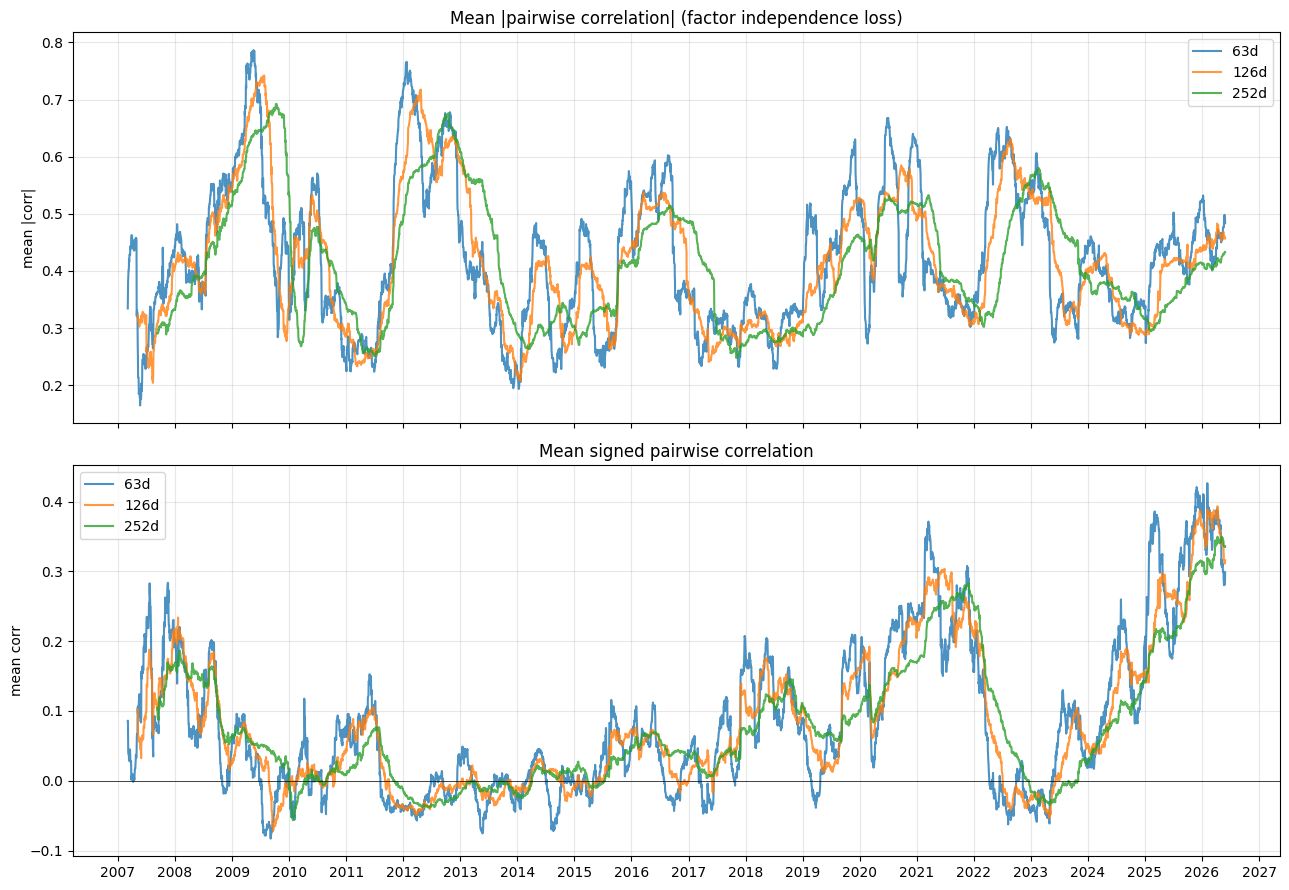

In [9]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# 上: 絶対値平均(D4の主シグナル)、複数窓
for w in windows:
    axes[0].plot(results[w]["abs"], label=f"{w}d", alpha=0.8)
axes[0].set_title("Mean |pairwise correlation| (factor independence loss)")
axes[0].set_ylabel("mean |corr|")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 下: 符号付き平均(同方向連動)
for w in windows:
    axes[1].plot(results[w]["signed"], label=f"{w}d", alpha=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Mean signed pairwise correlation")
axes[1].set_ylabel("mean corr")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
plt.tight_layout()


1. 絶対値平均相関(上パネル)— D4 に対してむしろ否定的

    直近2024–2026の絶対値平均相関は、252日窓で約0.40–0.45、504日窓で約0.34–0.38である。これを過去局面と比較する。

    過去の高相関局面: GFC(2009、126日で0.74)、2012(0.72)、2020–2021(0.58)はいずれも危機・ストレス局面で、相関が0.6–0.7に達した。
    過去の低ボラ局面(2013–2018): ここが D4 検証の鍵だった。この期間の絶対値平均相関は252/504日窓で約0.25–0.50のレンジで変動し、特に2014年と2017–2018年には0.25–0.30の低水準まで低下している。
    直近2024–2026: 約0.34–0.45。これは過去の低ボラ局面(2013–2018)の水準とおおむね同程度かやや高いが、危機局面の0.6–0.7には遠く及ばない。

    つまり、絶対値相関で見る限り、直近はファクター固有性が「歴史的に失われている」わけではない。0.40前後は全期間を通じて中庸の水準であり、2013–2018の低ボラ期と大差ない。D4 の「全ファクターが単一要因に支配され固有性を喪失」という強い主張は、絶対値相関の水準からは強くは支持されない。

2. 符号付き平均相関(下パネル)— こちらが決定的かつ異例

    下パネルが本当に注目すべき所見である。符号付き平均相関が、直近2024–2026で全観測期間の最高水準(126日で約0.38、504日でも約0.29)に達している。
    これは過去のどの局面より高い。GFC でも約0.2、2021–2022でも約0.2–0.28だった。直近の符号付き相関は、それらを超えて観測期間で前例のない水準にある。
    符号付き平均と絶対値平均の差が示す意味を解く。

    絶対値平均は中庸(0.4)、符号付き平均は最高(0.3–0.38) という組み合わせは、「ほとんどのファクターペアが正の相関で揃っている」ことを意味する。
    通常、ファクター間には構造的な負相関ペア(Value–Growth、Value–Momentum 等)が存在し、これが符号付き平均を押し下げる。符号付き平均が絶対値平均に接近している(0.3 vs 0.4)ということは、本来負相関だったペアの負相関が消failed、ほぼ全ペアが同方向に動いている。
    これは「6ファクターが互いに区別なく、同じ単一方向に連動している」状態であり、まさに単一要因支配=ファクター固有性の喪失そのものである。

3. 二つのパネルの統合解釈 — D4 は「符号構造の崩壊」として支持される

    当初 D4 の主シグナルと想定した絶対値平均では D4 は中庸にしか見えないが、符号付き平均が前例なき高水準という事実が、D4 を別の、より正確な形で支持する。
    直近のレジームの特徴は「相関が一様に強まった」ことではなく、「ファクター間の符号構造(分散をもたらす負相関ペア)が崩壊し、全ファクターが同方向化した」ことである。これは D4(単一レジーム支配)の精緻化された像である。ファクターが互いに打ち消し合う関係を失えば、マルチファクター・ポートフォリオの分散効果は消失し、個々のファクターの固有リターン源泉も消える。クオリティのボラ消失は、この「ファクター空間全体の同方向化・次元低下」の一部として説明される。
    López de Prado 的に言えば、ファクター・ユニバースの実効次元(effective rank)が直近で急低下している。15ペアが独立な情報を持つ正常な状態から、ほぼ1次元(全部同じ方向)へ縮約している。

4. ただし可逆性の判定は留保が必要

    ここが重要な分岐である。当初「直近が過去低ボラ期(2013–2018)と同水準なら可逆」という判定基準を立てた。しかし符号付き相関で見ると:
    - 2013–2018の符号付き平均相関は**ほぼゼロ(0.0前後)**だった。ファクターが互いに独立・直交していた健全な分散状態。
    - 直近2024–2026は0.3–0.38。2013–2018とは全く異なる。

    つまり直近の同方向化は、過去の低ボラ局面(2013–2018)には前例がない。2013–2018は「低ボラだが各ファクターは独立(符号付き≈0)」だったのに対し、直近は「同方向化(符号付き≈0.35)」という質的に異なる状態である。
    したがって「現状は過去の循環的低ボラ・レジームの再来=可逆」という単純な結論は下せない。直近の符号付き相関の前例なき高さは、むしろ新しい状態の可能性を示唆する。可逆性の判定には MS モデルによる確率的レジーム識別が必要になる。


## ファクターボラティリティ


### ローリングPCA


In [76]:
def rolling_pca_first_pc_ratio(
    vol_df: pd.DataFrame, window: int = 252, standardize: bool = True
) -> pd.DataFrame:
    """
    vol_df: 各ファクターの年率ボラ系列(列=6ファクター)
    window: ローリングPCA窓長
    standardize: 各窓内でz標準化するか(ファクター間のボラ水準差を除去)
    戻り値: 第1・第2主成分寄与率、第1主成分の各ファクター・ローディング
    """
    from sklearn.decomposition import PCA

    cols = vol_df.columns
    idx = vol_df.index
    rec = []
    for end in range(window, len(vol_df) + 1):
        win = vol_df.iloc[end - window : end].dropna()
        if len(win) < window * 0.8:
            continue
        X = win.values
        if standardize:
            X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
        pca = PCA()
        pca.fit(X)
        evr = pca.explained_variance_ratio_
        loadings = pca.components_[0]  # 第1主成分のローディング
        row = {
            "date": idx[end - 1],
            "pc1_ratio": evr[0],
            "pc2_ratio": evr[1] if len(evr) > 1 else np.nan,
        }
        for c, l in zip(cols, loadings):
            row[f"load_{c}"] = l
        rec.append(row)
    return pd.DataFrame(rec).set_index("date")


### リターン系列を変換

- $r \rightarrow |r|$
- $r \rightarrow r^2$
- $r \rightarrow \log({r^2 + \epsilon})$


In [77]:
for sector in dfs_return_data_by_sector.keys():
    for factor in ["Growth", "Low Volatility", "Momentum", "Quality", "Size", "Value"]:
        # 絶対値
        dfs_return_data_by_sector[sector][f"{factor}_abs"] = dfs_return_data_by_sector[
            sector
        ][factor].abs()

        # 2乗
        dfs_return_data_by_sector[sector][f"{factor}_squared"] = np.power(
            dfs_return_data_by_sector[sector][factor], 2
        )

        # log(r^2+1e-08)
        dfs_return_data_by_sector[sector][f"{factor}_log-squared"] = np.log(
            np.power(dfs_return_data_by_sector[sector][factor], 2) + 1e-12
        )

display(dfs_return_data_by_sector["Sector Neutralized"].head())


,Growth,Low Volatility,Momentum,Quality,Size,Value,Growth_abs,Growth_squared,Growth_log-squared,Low Volatility_abs,...,Momentum_log-squared,Quality_abs,Quality_squared,Quality_log-squared,Size_abs,Size_squared,Size_log-squared,Value_abs,Value_squared,Value_log-squared
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-02,-0.0002,0.0009,0.0005,-0.0001,-0.0016,0.0026,0.0002,4.000000e-08,-17.034361,0.0009,...,-15.201801,0.0001,1.000000e-08,-18.420581,0.0016,2.560000e-06,-12.875503,0.0026,0.000007,-11.904488
2007-01-03,-0.0011,-0.0063,-0.0039,-0.0029,-0.0039,-0.0042,0.0011,1.210000e-06,-13.624889,0.0063,...,-11.093557,0.0029,8.410000e-06,-11.686089,0.0039,1.521000e-05,-11.093557,0.0042,0.000018,-10.945341
2007-01-04,-0.0011,-0.0069,-0.0073,-0.0017,-0.0002,-0.0047,0.0011,1.210000e-06,-13.624889,0.0069,...,-9.839762,0.0017,2.890000e-06,-12.754254,0.0002,4.000000e-08,-17.034361,0.0047,0.000022,-10.720385
2007-01-05,0.0019,-0.0027,-0.0043,0.0005,-0.0028,-0.0021,0.0019,3.610000e-06,-12.531803,0.0027,...,-10.898280,0.0005,2.500000e-07,-15.201801,0.0028,7.840000e-06,-11.756272,0.0021,0.000004,-12.331636
2007-01-08,0.0004,-0.0006,0.0000,0.0008,-0.0015,-0.0000,0.0004,1.600000e-07,-15.648086,0.0006,...,-27.631021,0.0008,6.400000e-07,-14.261796,0.0015,2.250000e-06,-13.004580,0.0000,0.000000,-27.631021


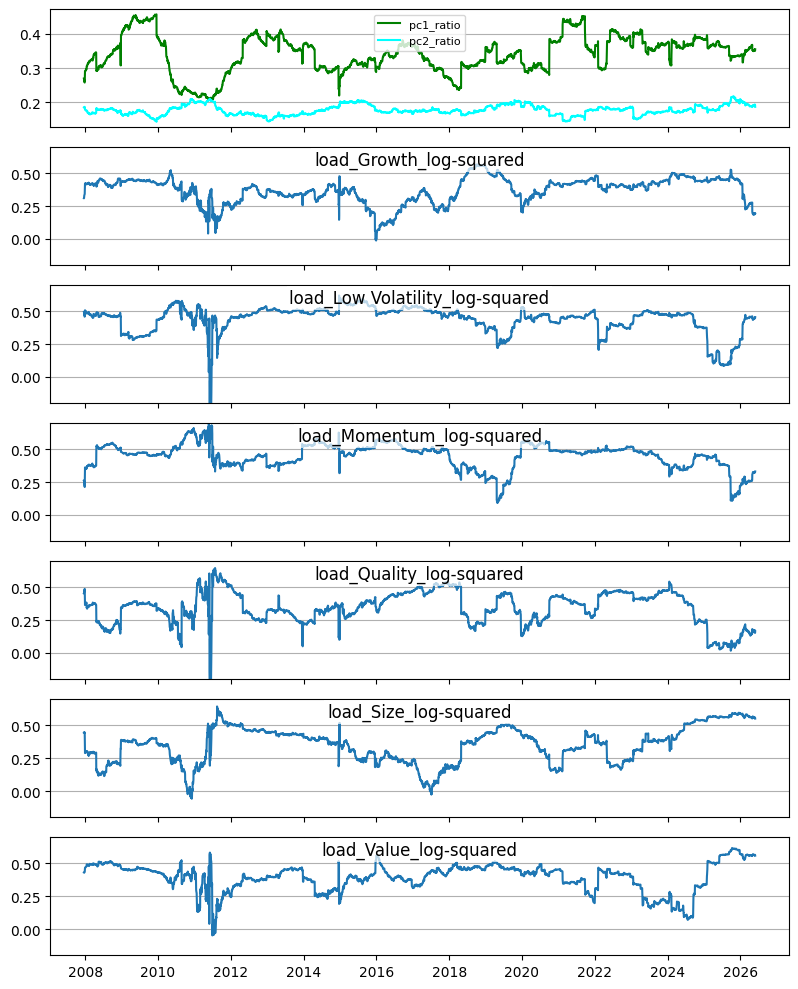

In [86]:
vol_cols = [
    c + "_log-squared"
    for c in ["Growth", "Low Volatility", "Momentum", "Quality", "Size", "Value"]
]
vol_df = dfs_return_data_by_sector["Materials"][vol_cols]
vol_df_res = rolling_pca_first_pc_ratio(vol_df=vol_df, standardize=True)

# display(vol_df_res)

fig, axes = plt.subplots(7, 1, figsize=(8, 10), tight_layout=True, sharex=True)
ax1 = axes[0]
ax1.plot(vol_df_res.index, vol_df_res["pc1_ratio"], label="pc1_ratio", color="green")
ax1.plot(vol_df_res.index, vol_df_res["pc2_ratio"], label="pc2_ratio", color="cyan")
ax1.legend(fontsize=8)
ax1.grid(axis="y")

for i, load in enumerate(
    [c for c in vol_df_res.columns if not c in ["pc1_ratio", "pc2_ratio"]]
):
    ax = axes[i + 1]
    ax.plot(vol_df_res.index, vol_df_res[load], label=load)
    ax.set_title(
        load,
        y=0.90,
        va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
    ax.set_ylim(-0.2, 0.7)
    ax.grid(axis="y")

plt.show()

# fig = go.Figure()
# for col in ["pc1_ratio", "pc2_ratio"]:
# # for col in [f"load_{c}" for c in vol_cols]:
#     fig.add_trace(
#         go.Scatter(x=vol_df_res.index, y=vol_df_res[col], mode="lines", name=col)
#     )
# fig.update_layout(template="plotly_dark", margin=dict(l=40, t=50, b=50, r=40))
# fig.update_xaxes(title="Date")
# fig.show()


第1主成分の Quality ローディング(load_Quality)が、直近2024–2026にかけて0.50前後から約0.25へ低下している。さらに遡ると2015年頃には一時マイナスまで沈んでいる。
ローディングの解釈は次の通りである。第1主成分(全ファクター共通のボラ因子)に対する各ファクターの感応度を表す。直近で:

- Low Volatility、Growth、Momentum、Value のローディングは0.40–0.50で高い → これらのボラは共通因子とよく連動。
- Quality のローディングだけが0.25へ低下 → クオリティのボラが、他ファクター共通のボラ因子から乖離している。

これは D4 にとって決定的に不利な所見である。もしクオリティのボラ消失が「市場全体の凪レジーム(D4)」由来なら、クオリティは共通ボラ因子に強く連動(高ローディング)するはずである。実際には逆で、クオリティのボラだけが共通因子から切り離されている。つまりクオリティのボラ消失は、市場全般のレジームでなくクオリティ固有の現象である可能性を、ボラ PCA は示している。
